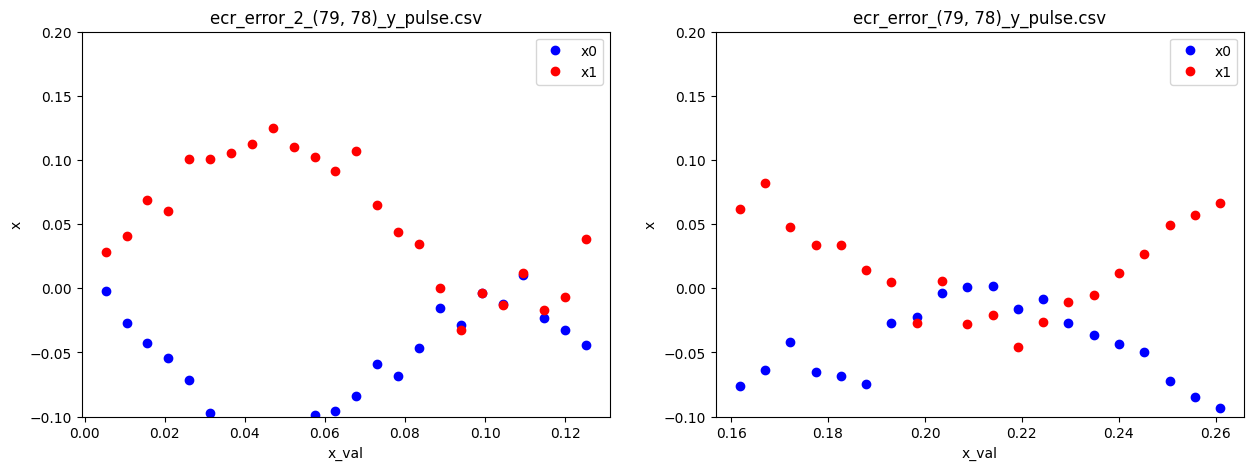

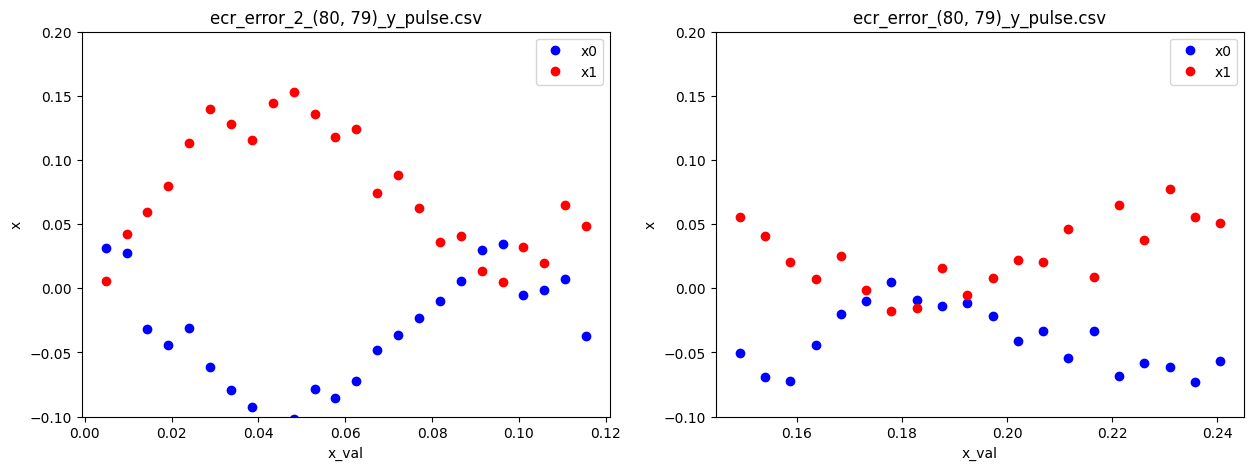

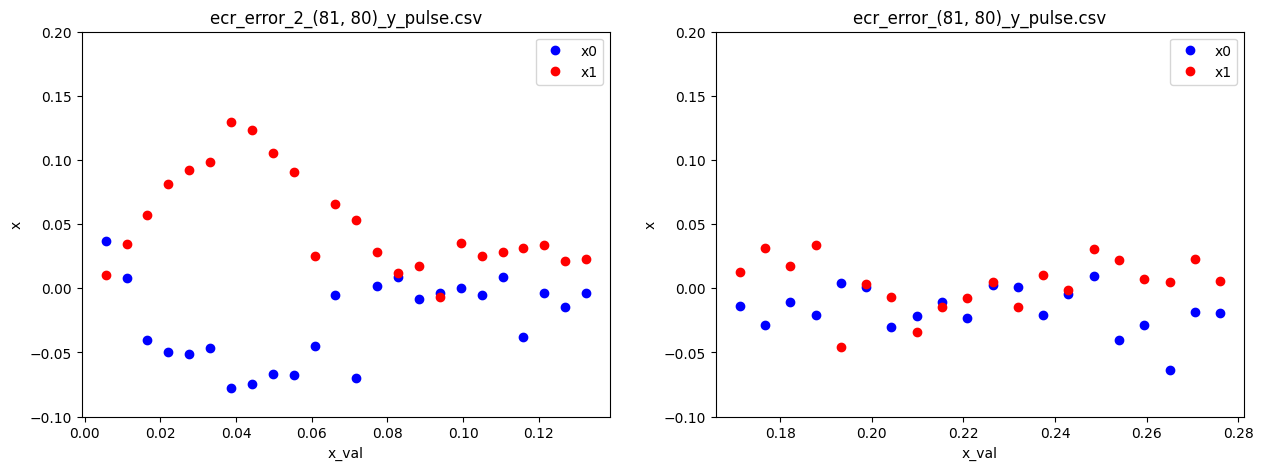

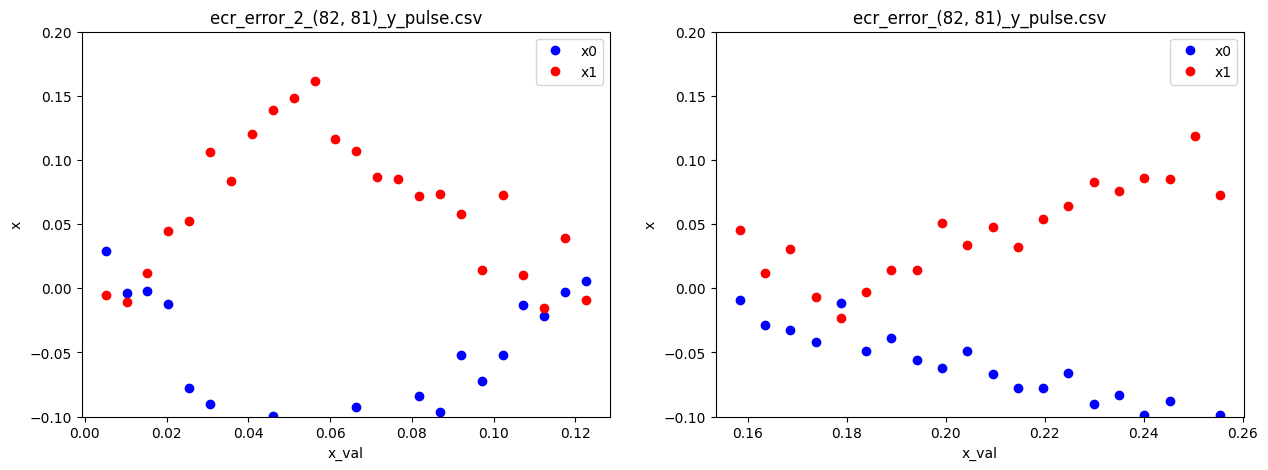

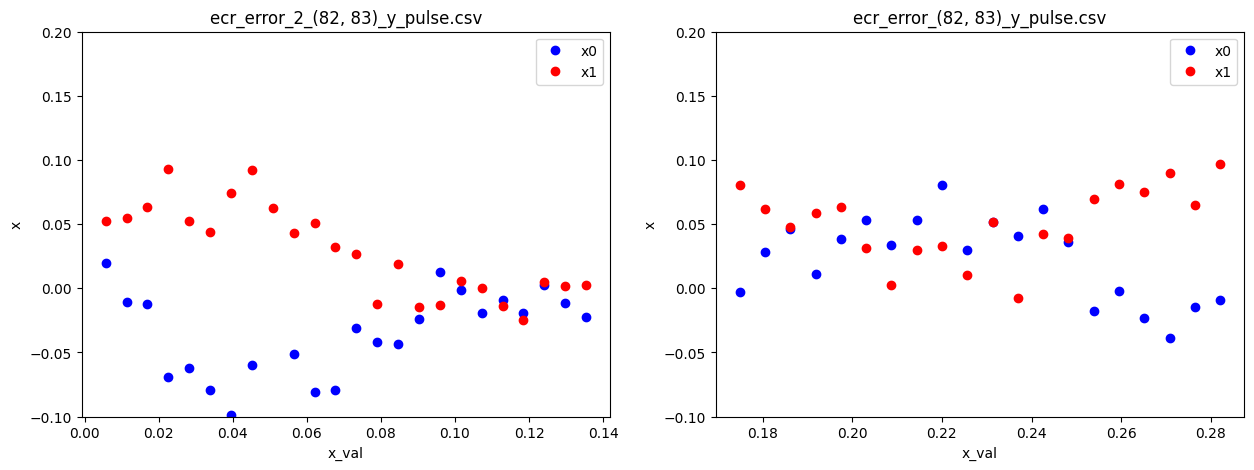

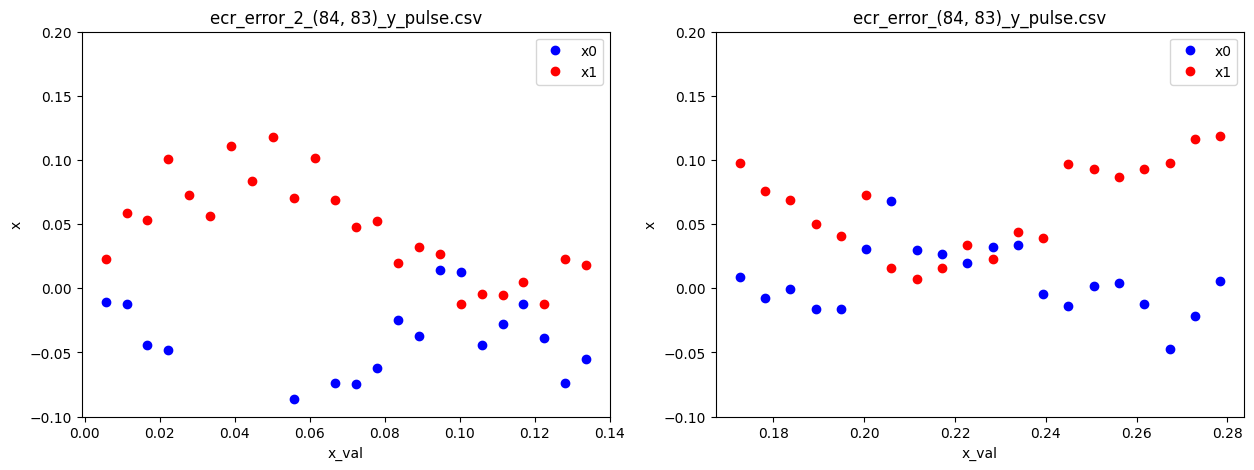

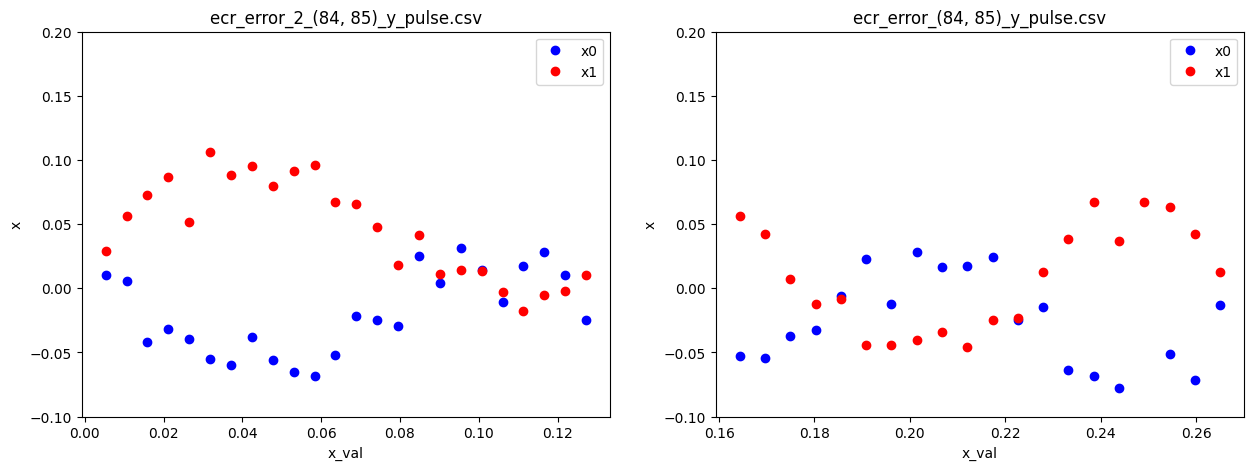

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
directory =  'ibm_kyoto'
# 현재 디렉토리 내의 조건에 맞는 파일 목록 가져오기
files_starts_with_ecr_1 = [f for f in os.listdir(directory) if f.startswith('ecr_error_(')]
files_starts_with_ecr = [f for f in os.listdir(directory) if f.startswith('ecr_error_2')]

# 서브플롯의 개수 설정

meas_basis = 'x'
# 첫 번째 subplot: ).csv로 끝나는 파일들
for index,file in enumerate(files_starts_with_ecr):
    # CSV 파일 읽기
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    files_starts_with_ecr_1[index]
    df_1 = pd.read_csv(os.path.join(directory, file))
    df_2 = pd.read_csv(os.path.join(directory, files_starts_with_ecr_1[index]))
    # 데이터 플롯
    axs[0].plot(df_1['xval'], df_1[f'{meas_basis}0'],'bo', label=f'{meas_basis}0')
    axs[0].plot(df_1['xval'], df_1[f'{meas_basis}1'],'ro', label=f'{meas_basis}1')
    # 첫 번째 subplot 설정
    axs[0].set_title(file)
    axs[0].set_xlabel('x_val')
    axs[0].set_ylabel('x')
    axs[0].legend()
    if max(df_1[f'{meas_basis}0'])>0.5:
        z = True
    else:
        z = False
    if z:
        axs[0].set_ylim(0.8, 1)
    else:
        axs[0].set_ylim(-0.1, 0.2)
    # 데이터 플롯
    axs[1].plot(df_2['xval'], df_2[f'{meas_basis}0'],'bo', label=f'{meas_basis}0')
    axs[1].plot(df_2['xval'], df_2[f'{meas_basis}1'],'ro', label=f'{meas_basis}1')
    # 첫 번째 subplot 설정
    axs[1].set_title(files_starts_with_ecr_1[index])
    axs[1].set_xlabel('x_val')
    axs[1].set_ylabel('x')
    axs[1].legend()
    if max(df_2[f'{meas_basis}0'])>0.5:
        z = True
    else:
        z = False
    if z:
        axs[1].set_ylim(0.8, 1)
    else:
        axs[1].set_ylim(-0.1, 0.2)










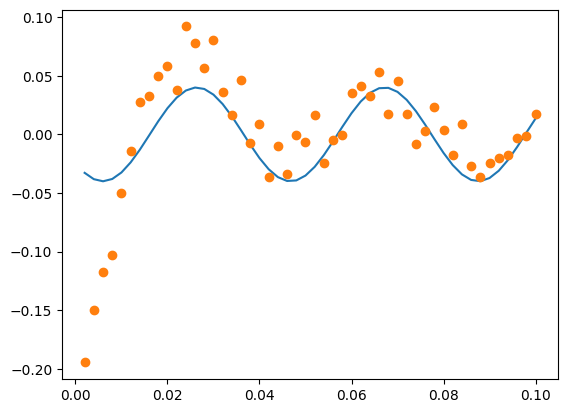

In [22]:
import pandas as pd 
from scipy.optimize import curve_fit
import numpy as np
from matplotlib import pyplot as plt

# 모델 함수 정의
def sin_model(x, a, b, c):
    return a * np.sin(b * x + c)

# 초기 추정값 설정 함수
def initial_guess(x, y):
    # 진폭 추정 (최대값 - 최소값) / 2
    a = (np.max(y) - np.min(y)) / 2
    
    # 주기 추정: 주기를 추정하기 위해 FFT 사용
    freqs = np.fft.fftfreq(len(x), x[1] - x[0])
    fft_spectrum = np.fft.fft(y - np.mean(y))
    b = 2 * np.pi * abs(freqs[np.argmax(np.abs(fft_spectrum[1:])) + 1])
    
    # 위상 추정
    c = 0  # 위상은 0으로 초기화 (더 정밀한 방법이 필요할 수 있음)
    return [a, b, c]

data = pd.read_csv("(94, 95).csv")

x_data = data['xval']
x_measure_data = data['x1']
y_measure_data = data['y0']

def find_fit(x,y):
    guess = initial_guess(x,y)
    params,_ = curve_fit(sin_model,x,y,p0 = guess)
    return params


res = find_fit(x_data,y_measure_data) 
res[0] = 0.04
fit_data = sin_model(x_data,*res)
plt.plot(x_data,fit_data)
plt.plot(x_data,x_measure_data,'o')

In [34]:
import os
import pandas as pd
import re

# Initialize an empty dictionary to store the results
X_dict = {}

# Specify the directory to search for CSV files
directory = 'temp'

# Get a list of all CSV files in the specified directory
csv_files = [file for file in os.listdir(directory) if file.endswith('.csv') and file.startswith('ecr_error_(')]

# Regular expression to extract (q_index1, q_index2) from the file name
pattern = re.compile(r'ecr_error_\((\d+),\s*(\d+)\)_y_pulse.csv')

for file in csv_files:
    match = pattern.match(file)
    if match:
        q_index1 = int(match.group(1))
        q_index2 = int(match.group(2))
        
        # Read the CSV file into a DataFrame
        df = pd.read_csv(os.path.join(directory, file))
        
        # Filter rows where the index is greater than 5
        filtered_df = df[df.index > 5]
        
        # Get the row with the minimum value in ['x0']
        min_x0_row = filtered_df.loc[(abs(filtered_df['x1']) + abs(filtered_df['x0'])).idxmin()]
        print((abs(filtered_df['x1']) + abs(filtered_df['x0'])).min())
        print(filtered_df['z1'])
        # Get the ['xval'] value from the row with the minimum ['x0']
        xval = min_x0_row['xval']
        
        # Store the result in the dictionary
        X_dict[(q_index1, q_index2)] = xval

# Print the results
print(X_dict)



0.009
6     0.9645
7     0.9645
8     0.9650
9     0.9725
10    0.9680
11    0.9635
12    0.9670
13    0.9670
14    0.9665
15    0.9615
16    0.9610
17    0.9565
18    0.9660
19    0.9605
Name: z1, dtype: float64
0.0164999999999999
6     0.9440
7     0.9480
8     0.9520
9     0.9350
10    0.9490
11    0.9465
12    0.9470
13    0.9460
14    0.9450
15    0.9445
16    0.9460
17    0.9525
18    0.9440
19    0.9385
Name: z1, dtype: float64
0.0059999999999998995
6     0.9375
7     0.9455
8     0.9365
9     0.9375
10    0.9395
11    0.9310
12    0.9385
13    0.9290
14    0.9385
15    0.9370
16    0.9445
17    0.9400
18    0.9325
19    0.9370
Name: z1, dtype: float64
0.0524999999999999
6     0.9165
7     0.9170
8     0.9180
9     0.9165
10    0.9225
11    0.9165
12    0.9205
13    0.9190
14    0.9245
15    0.9120
16    0.9355
17    0.9225
18    0.9265
19    0.9255
Name: z1, dtype: float64
0.0364999999999999
6     0.9610
7     0.9645
8     0.9660
9     0.9620
10    0.9735
11    0.9595
12    0.9

In [30]:
csv_files

['ecr_error_(79, 78)_y_pulse.csv',
 'ecr_error_(80, 79)_y_pulse.csv',
 'ecr_error_(81, 80)_y_pulse.csv',
 'ecr_error_(82, 81)_y_pulse.csv',
 'ecr_error_(82, 83)_y_pulse.csv',
 'ecr_error_(84, 83)_y_pulse.csv',
 'ecr_error_(84, 85)_y_pulse.csv']

In [2]:
from functions.Train_ZNE import *
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit.circuit.library import RealAmplitudes,EfficientSU2

service = QiskitRuntimeService(channel='ibm_quantum',
    instance='ibm-q-skku/skku/skku-students',
    token = '06f802eeac992c43c4106753d7c5fc31414a13eb7d91c99d67fb49cc50569e5b4b011f20c71b9607a07cb43ecc7044557c699022db91d1685ba4c886d5886854')
backend = service.backend('ibm_kyoto')


config = {'backend':backend,'x_amp_dict':X_dict,'error_stretch':1.,'ecr_stretch':1.,'l':0}

In [3]:
temp_class = train_ZNE(20,**config)

In [4]:
class_id = 'eed97a17-dcbf-4620-8a71-d4a057bc2e3b'
temp_class.load_data(class_id)

In [31]:
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
import numpy as np
from qiskit.compiler import transpile
from qiskit_ibm_runtime.options import TwirlingOptions
from qiskit.quantum_info import SparsePauliOp
import uuid
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
def create_trotterized_ising_model_circuit(num_qubits, trotter_steps, time):
    """
    Trotterization을 사용하여 Ising 모델의 양자 서킷을 생성합니다.
    각 Rz 게이트의 파라미터는 Qiskit Parameter로 동적으로 설정됩니다.

    Parameters:
    - num_qubits: 큐비트의 수
    - trotter_steps: Trotterization 단계 수
    - time: 진화 시간

    Returns:
    - QuantumCircuit: 생성된 양자 서킷
    - dict: 서킷 파라미터 사전
    """
    qc = QuantumCircuit(num_qubits)
    delta_t = 1

    # 파라미터 설정
    h_params = [Parameter(f'h_{i}') for i in range(num_qubits)]
    J_params = [[Parameter(f'J_{i}_{j}') for j in range(num_qubits)] for i in range(num_qubits)]

    for _ in range(trotter_steps):
        # 자기 상호작용 항목 추가
        
        for i in range(num_qubits):
            qc.rx(2 * h_params[i] * delta_t, i)

        # 스핀 간 상호작용 항목 추가
        for i in range(num_qubits-1):
            if J_params[i][i+1] != 0:
                qc.cx(i, i+1)
                qc.rz(2 * J_params[i][i+1] * delta_t, i+1)
                qc.cx(i, i+1)

    return qc, h_params, J_params


# ECR 게이트를 제거하는 함수
def remove_ecr_gates(circuit):
    new_circuit = QuantumCircuit(circuit.num_qubits)
    for instr, qargs, cargs in circuit.data:
        if instr.name != 'ecr':
            new_circuit.append(instr, qargs, cargs)
    return new_circuit

# 파라미터 설정
trotter_steps = 3  # Trotterization 단계 수
time = 1.0  # 진화 시간
num_qubits = 8
init_p  =['I' for i in range(num_qubits)]
p_list = []
for i in range(num_qubits):
    temp = init_p.copy()
    temp[i] = 'Z'
    p_list.append(''.join(temp))


hamiltonian = SparsePauliOp.from_list([(p_list[i],1) for i in range(num_qubits)])
trotterized_ising_circuit, h_params, J_params = create_trotterized_ising_model_circuit(8, trotter_steps, time)

In [32]:
ZNE_temp = ZNE(trotterized_ising_circuit,hamiltonian,**config)

In [33]:
ZNE_temp.make_data()

KeyboardInterrupt: 

In [5]:
result = temp_class.get_data()

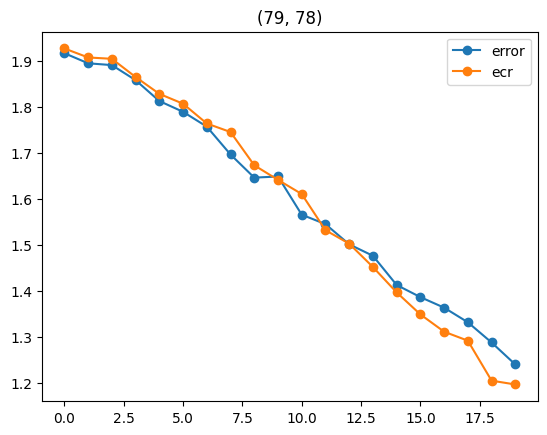

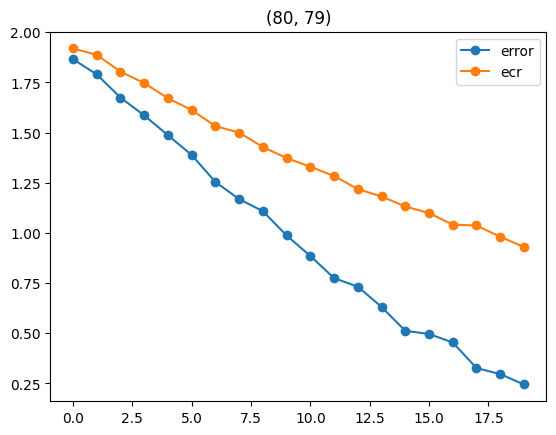

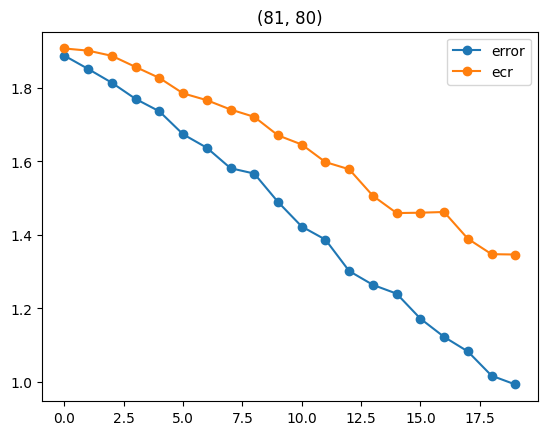

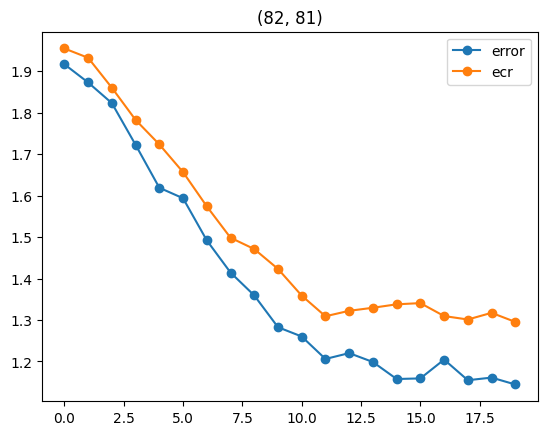

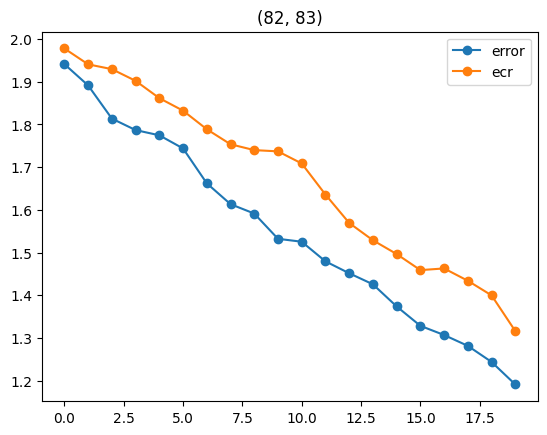

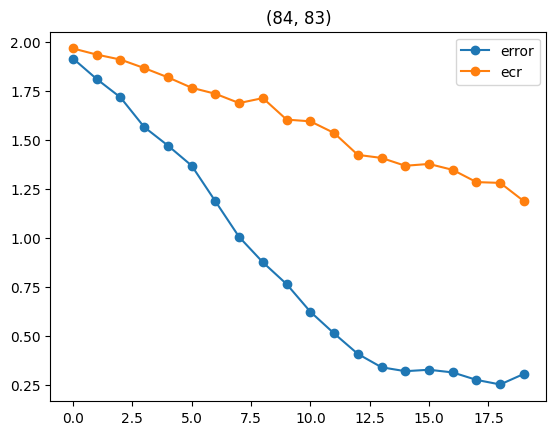

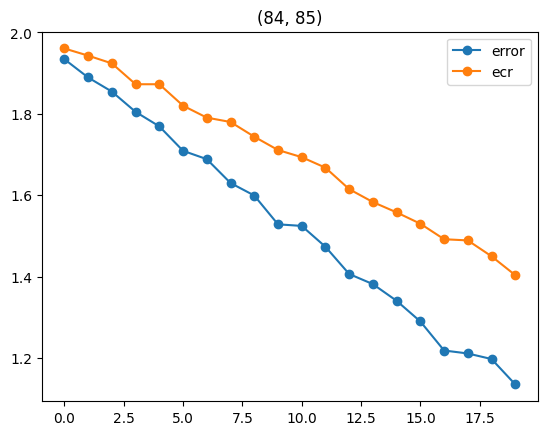

In [29]:
from matplotlib import pyplot as plt
for key in X_dict.keys():
    data_error = result[f'{list(key)}_even']
    data_ecr = result[f'{list(key)}_ecr']
    plt.figure()
    plt.title(key)
    plt.plot(data_error,'o-',label='error')
    plt.plot(data_ecr,'o-',label='ecr')
    plt.legend()
    plt.show()

In [41]:
import os
import pandas as pd
import re

# Initialize an empty dictionary to store the results
X_dict = {}

# Specify the directory to search for CSV files
directory = 'ibm_osaka'

# Get a list of all CSV files in the specified directory
csv_files = [file for file in os.listdir(directory) if file.endswith('.csv') and file.startswith('ecr_error_')]

# Regular expression to extract (q_index1, q_index2) from the file name
pattern = re.compile(r'ecr_error_\d+_\((\d+),\s*(\d+)\)_y_pulse.csv')

for file in csv_files:
    match = pattern.match(file)
    if match:
        q_index1 = int(match.group(1))
        q_index2 = int(match.group(2))
        
        # Read the CSV file into a DataFrame
        df = pd.read_csv(os.path.join(directory, file))
        
        # Filter rows where the index is greater than 5
        filtered_df = df[df.index > 5]
        
        # Get the row with the minimum value in ['x0']
        min_x0_row = filtered_df.loc[(abs(filtered_df['x1']) + abs(filtered_df['x0'])).idxmin()]
        print((abs(filtered_df['x1']) + abs(filtered_df['x0'])).min())
        # Get the ['xval'] value from the row with the minimum ['x0']
        xval = min_x0_row['xval']
        
        # Store the result in the dictionary
        X_dict[(q_index1, q_index2)] = xval
X_dict

0.017999999999999898
0.1164999999999998
0.004
0.0035
0.0114999999999998
0.0144999999999999
0.0289999999999999


{(100, 99): 0.09679704473258,
 (101, 100): 0.1089248530820584,
 (94, 95): 0.0839491578128234,
 (96, 95): 0.0860918485934419,
 (96, 97): 0.082204261452346,
 (97, 98): 0.0553878640961855,
 (99, 98): 0.1010473869804838}

In [44]:
from functions.Train_ZNE import *
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit.circuit.library import RealAmplitudes,EfficientSU2

service = QiskitRuntimeService(channel='ibm_quantum',
    instance='ibm-q-skku/skku/skku-students',
    token = '06f802eeac992c43c4106753d7c5fc31414a13eb7d91c99d67fb49cc50569e5b4b011f20c71b9607a07cb43ecc7044557c699022db91d1685ba4c886d5886854')
backend = service.backend('ibm_osaka')


config = {'backend':backend,'x_amp_dict':X_dict,'error_stretch':1.,'ecr_stretch':1.,'l':0}

In [45]:
temp_class = train_ZNE(20,**config)
temp_class.run()

In [46]:
ZNE_temp = ZNE(trotterized_ising_circuit,hamiltonian,**config)
ZNE_temp.make_data()

In [18]:
data_1[key_list[-7+index%7]]

0     1.921387
1     1.915527
2     1.874023
3     1.829590
4     1.779785
5     1.733398
6     1.680664
7     1.615234
8     1.591797
9     1.491699
10    1.471191
11    1.443359
12    1.395020
13    1.354004
14    1.341309
15    1.262207
16    1.274414
17    1.216309
18    1.176270
19    1.103027
Name: [80, 79]_ecr, dtype: float64

[79, 78]_ecr
[80, 79]_ecr
[81, 80]_ecr
[82, 81]_ecr
[82, 83]_ecr
[84, 83]_ecr
[84, 85]_ecr


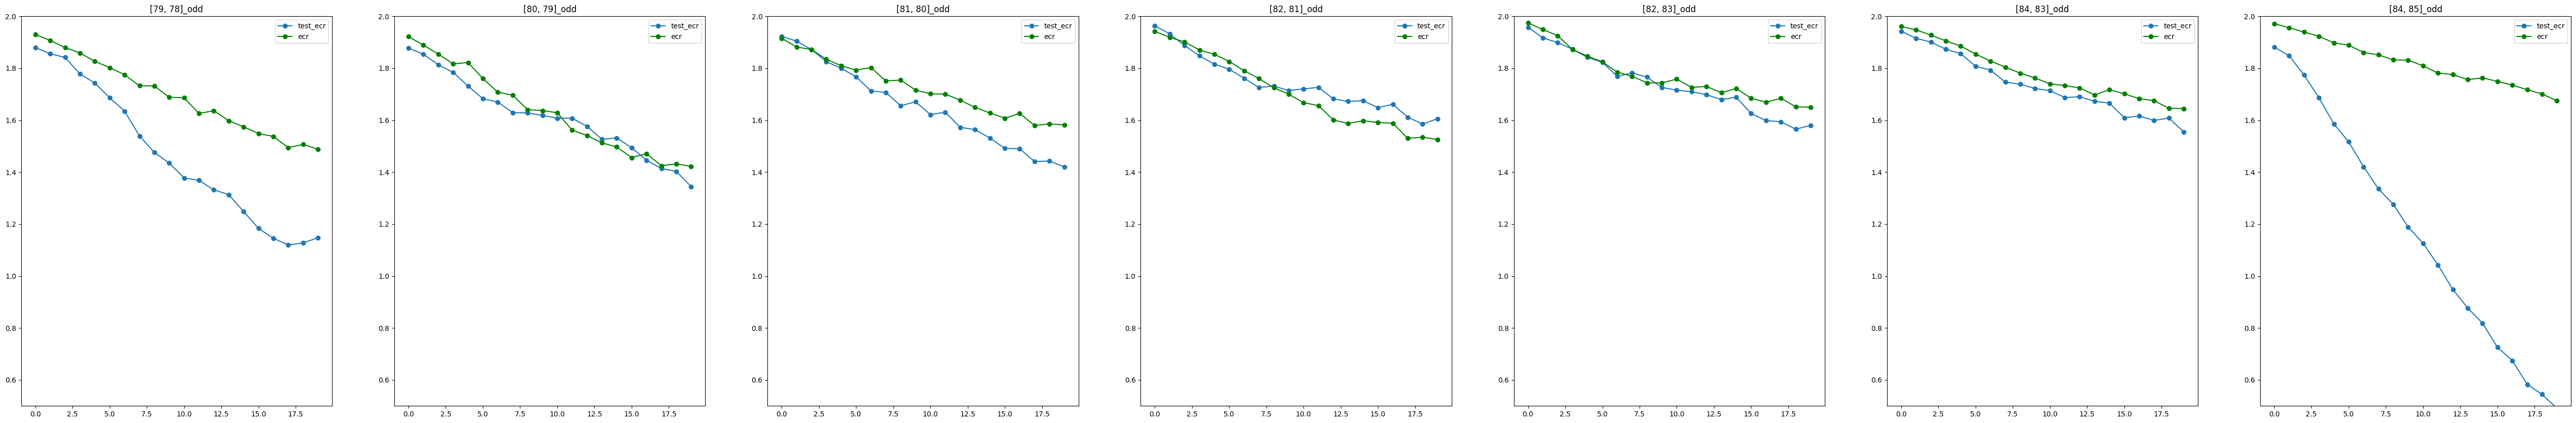

[79, 78]_ecr
[80, 79]_ecr
[81, 80]_ecr
[82, 81]_ecr
[82, 83]_ecr
[84, 83]_ecr
[84, 85]_ecr


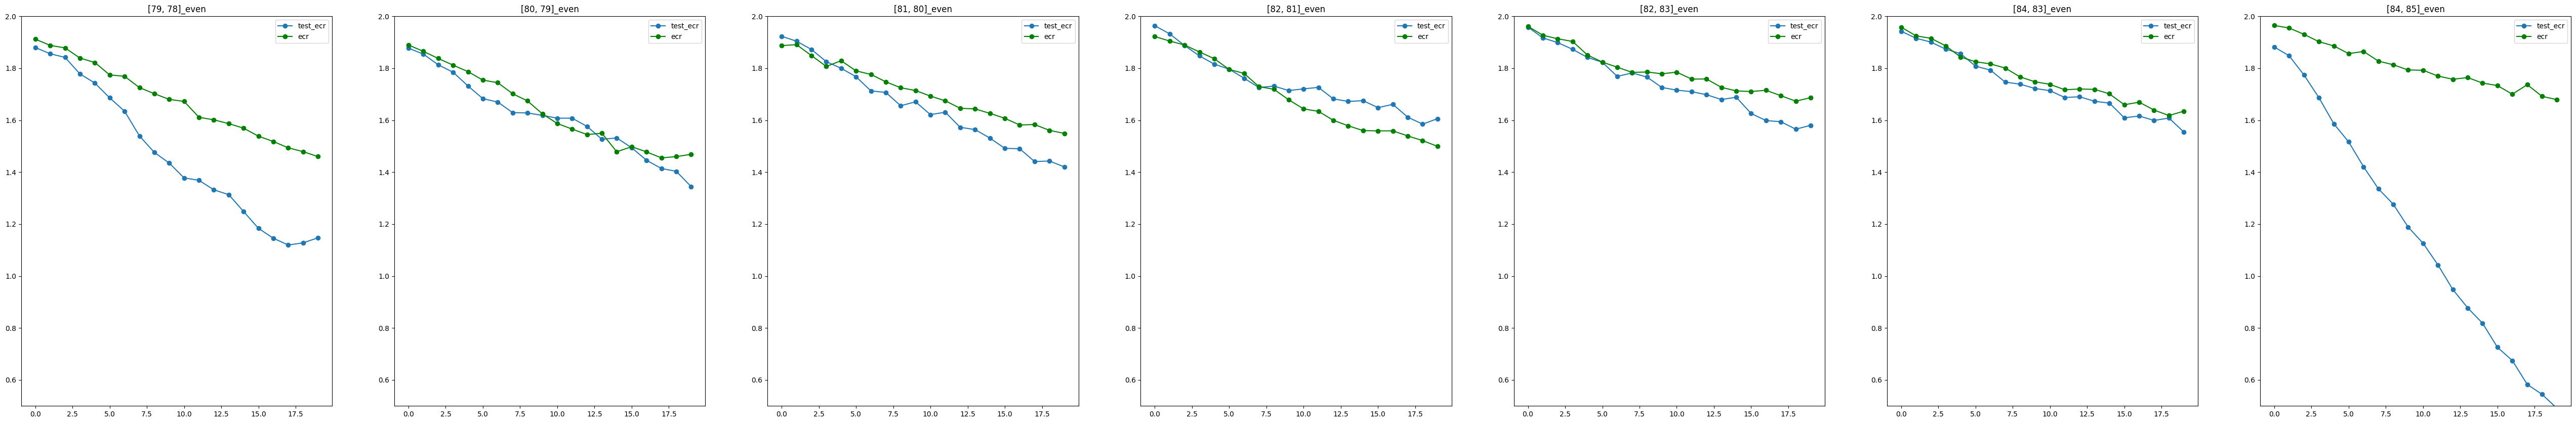

[79, 78]_ecr
[80, 79]_ecr
[81, 80]_ecr
[82, 81]_ecr
[82, 83]_ecr
[84, 83]_ecr
[84, 85]_ecr


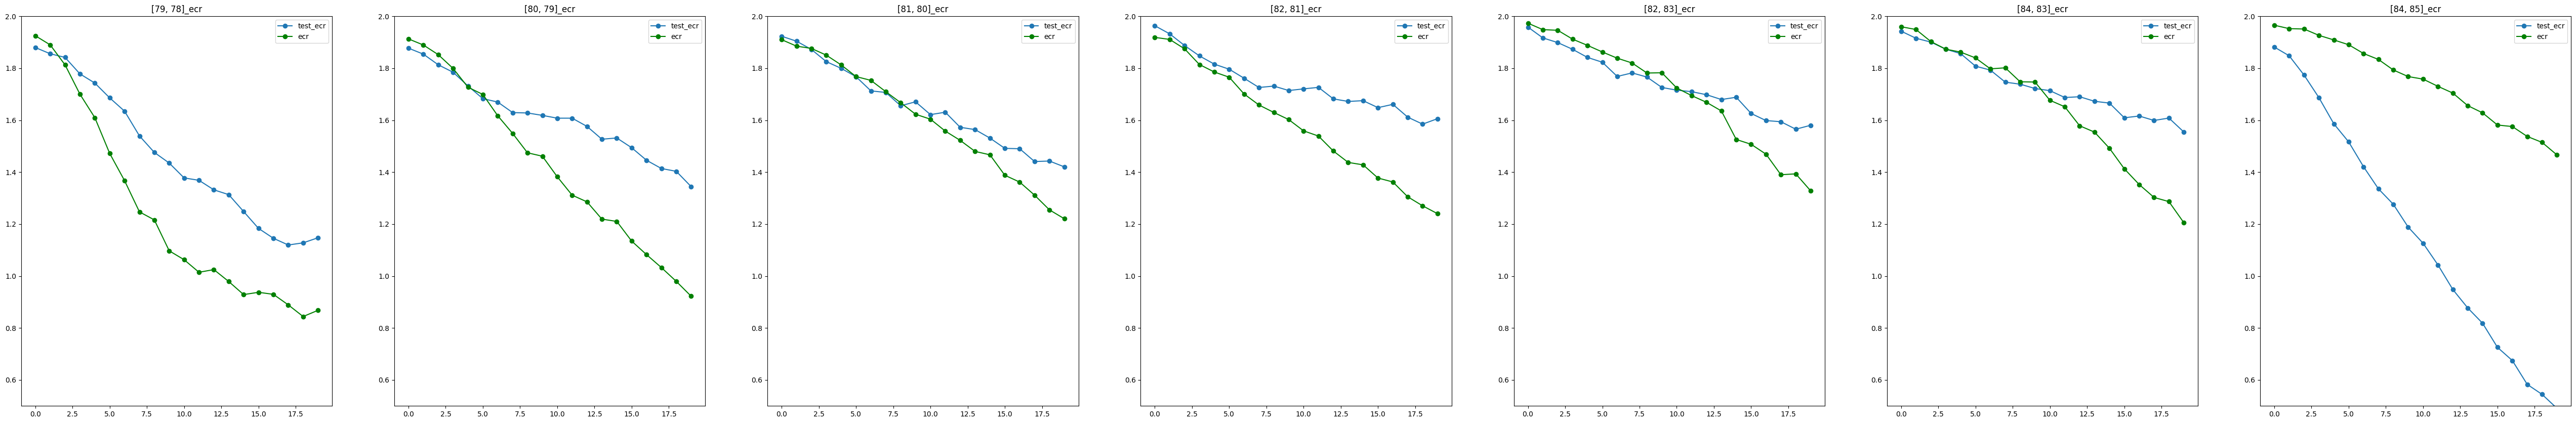

In [1]:
import pandas as pd

data_1 = pd.read_csv('./ecr_compare_result/1.3_data_ibm_kyoto.csv')
data_2 = pd.read_csv('./ecr_compare_result/1_data_ibm_kyoto.csv')
from matplotlib import pyplot as plt
index = 0
key_list = list(data_1.keys())
for key in data_1.keys():
    if index%7==1:
        plt.figure(figsize=(65,10))
    if index ==0:
        index+=1
        continue
    
    temp_index = index%7
    if temp_index == 0:
        temp_index = 7
    plt.subplot(1,7,temp_index)
    plt.title(key)
    print(key_list[-7+temp_index-1])
    plt.plot(data_1[key_list[-14+index%7]],'o-',label='test_ecr')
    #plt.plot(data_2[key_list[-7+temp_index-1]],'o-',label='test_ecr_stretch')
    #plt.plot(data_1[key],'o-',label='error')
    plt.plot(data_2[key],'go-',label='ecr')
    plt.ylim(0.5,2)
    plt.legend()
    if index%7==0:
        plt.show()
    index+=1
plt.show()

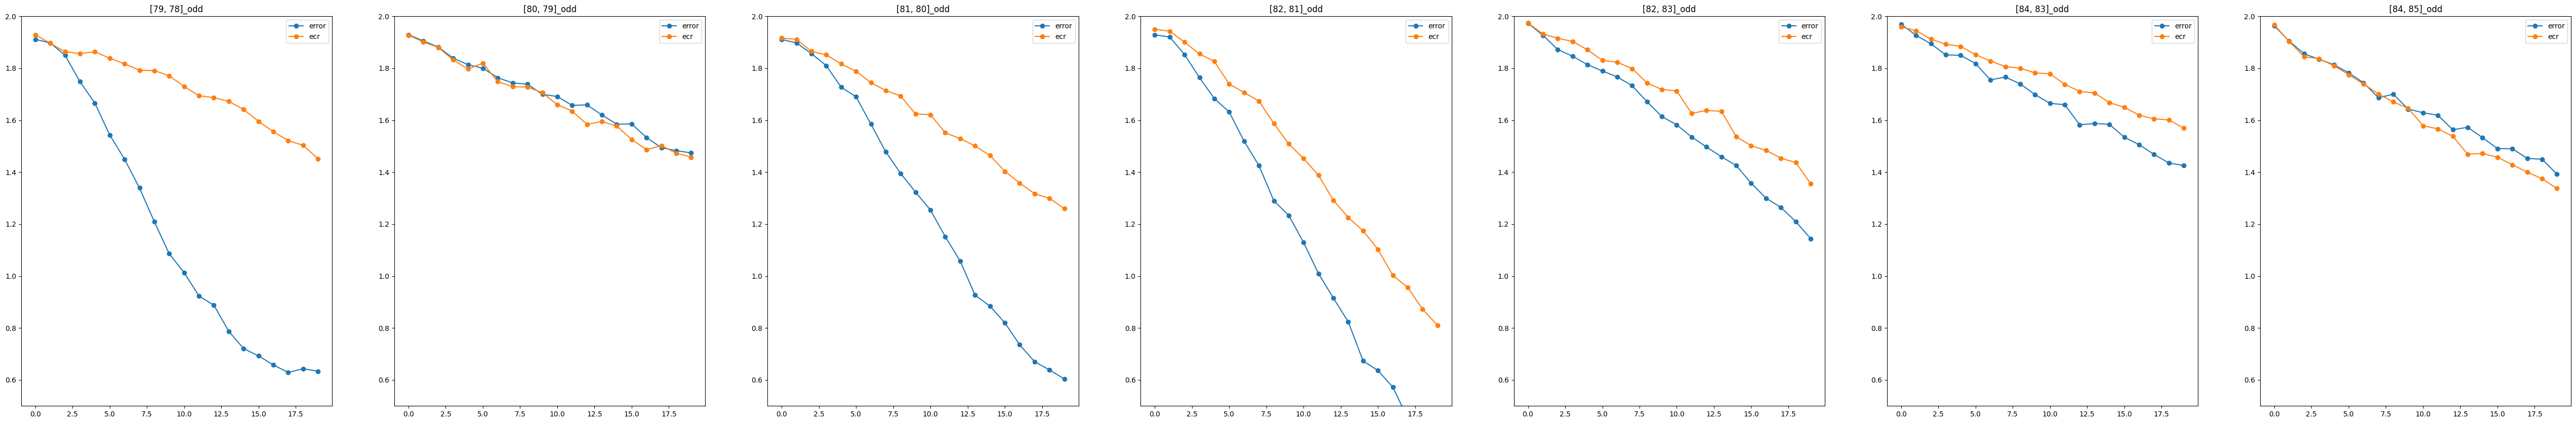

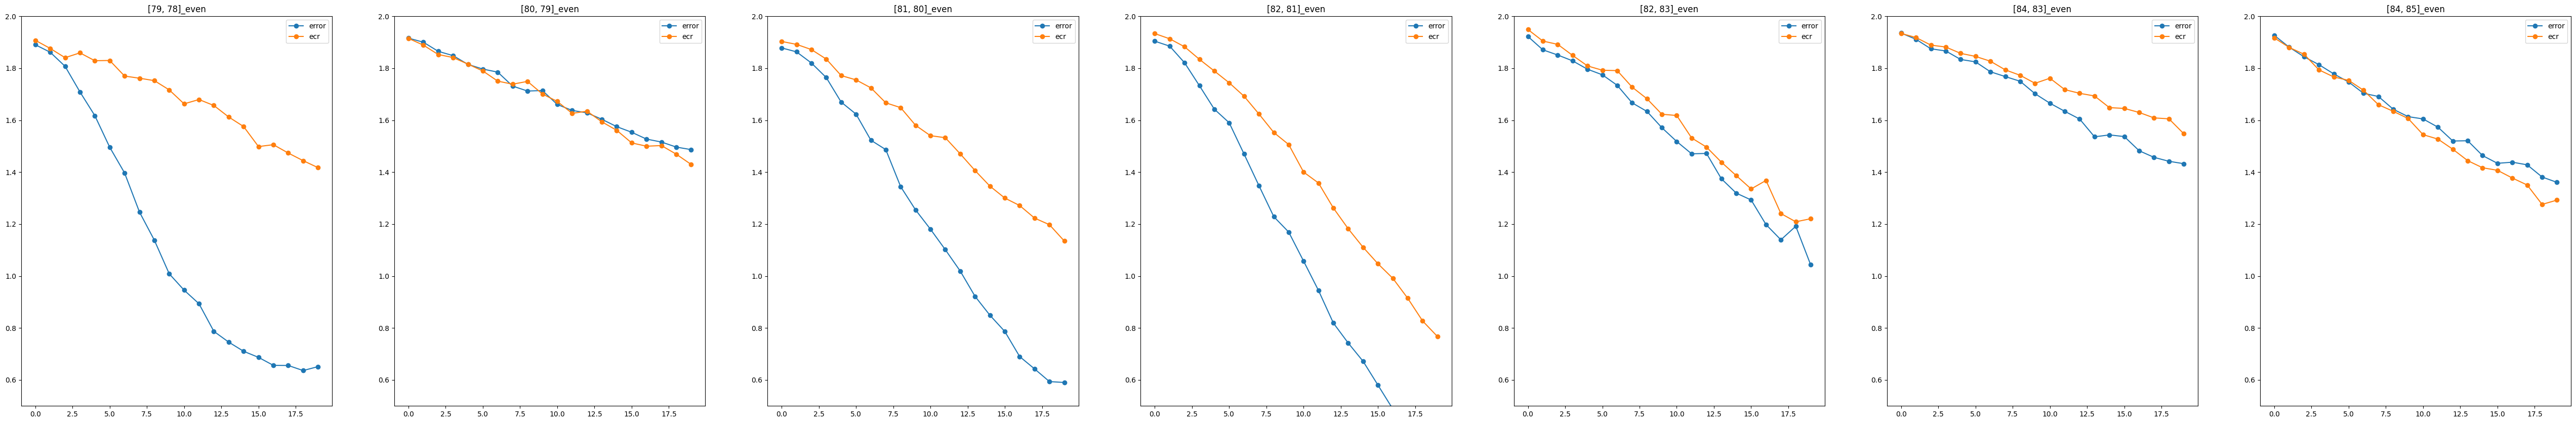

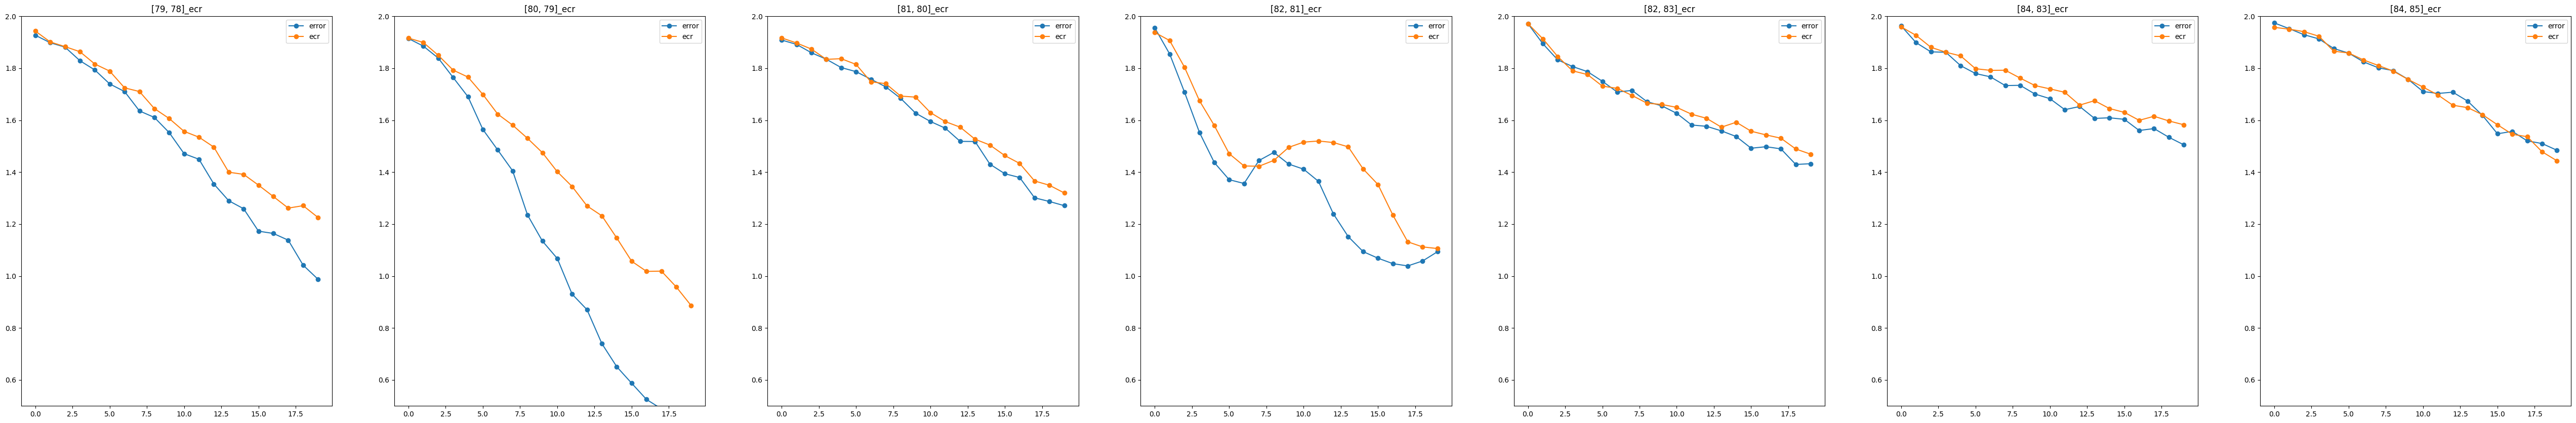

In [8]:
import pandas as pd

data_1 = pd.read_csv('./ecr_compare_result/1.1_data_ibm_kyoto.csv')
data_2 = pd.read_csv('./ecr_compare_result/1_data_ibm_kyoto.csv')
from matplotlib import pyplot as plt
index = 0

for key in data_1.keys():
    if index%7==1:
        plt.figure(figsize=(65,10))
    if index ==0:
        index+=1
        continue
    
    temp_index = index%7
    if temp_index == 0:
        temp_index = 7
    plt.subplot(1,7,temp_index)
    plt.title(key)
    plt.plot(data_1[key],'o-',label='error')
    plt.plot(data_2[key],'o-',label='ecr')
    plt.ylim(0.5,2)
    plt.legend()
    if index%7==0:
        plt.show()
    index+=1
plt.show()